In [1]:
%store -r bar_data_HIST_TRMM19852014_minus_TRMM

%store -r bar_data_G6sulfur20212100_minus_HIST19212000
%store -r bar_data_SSP58520212100_minus_HIST19212000
%store -r bar_data_SSP24520212100_minus_HIST19212000

%store -r bar_data_G6sulfur20212100_minus_SSP24520212100
%store -r bar_data_G6sulfur20212100_minus_SSP58520212100



Available labels: ['Land', 'Ocean', 'N. America', 'S. America', 'Sahel', 'S. Africa', 'India', 'N. Australia']


/tmp/ipykernel_16950/3343030317.py:79: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.scatter(np.full(len(pm), float(x + offset)), pm,


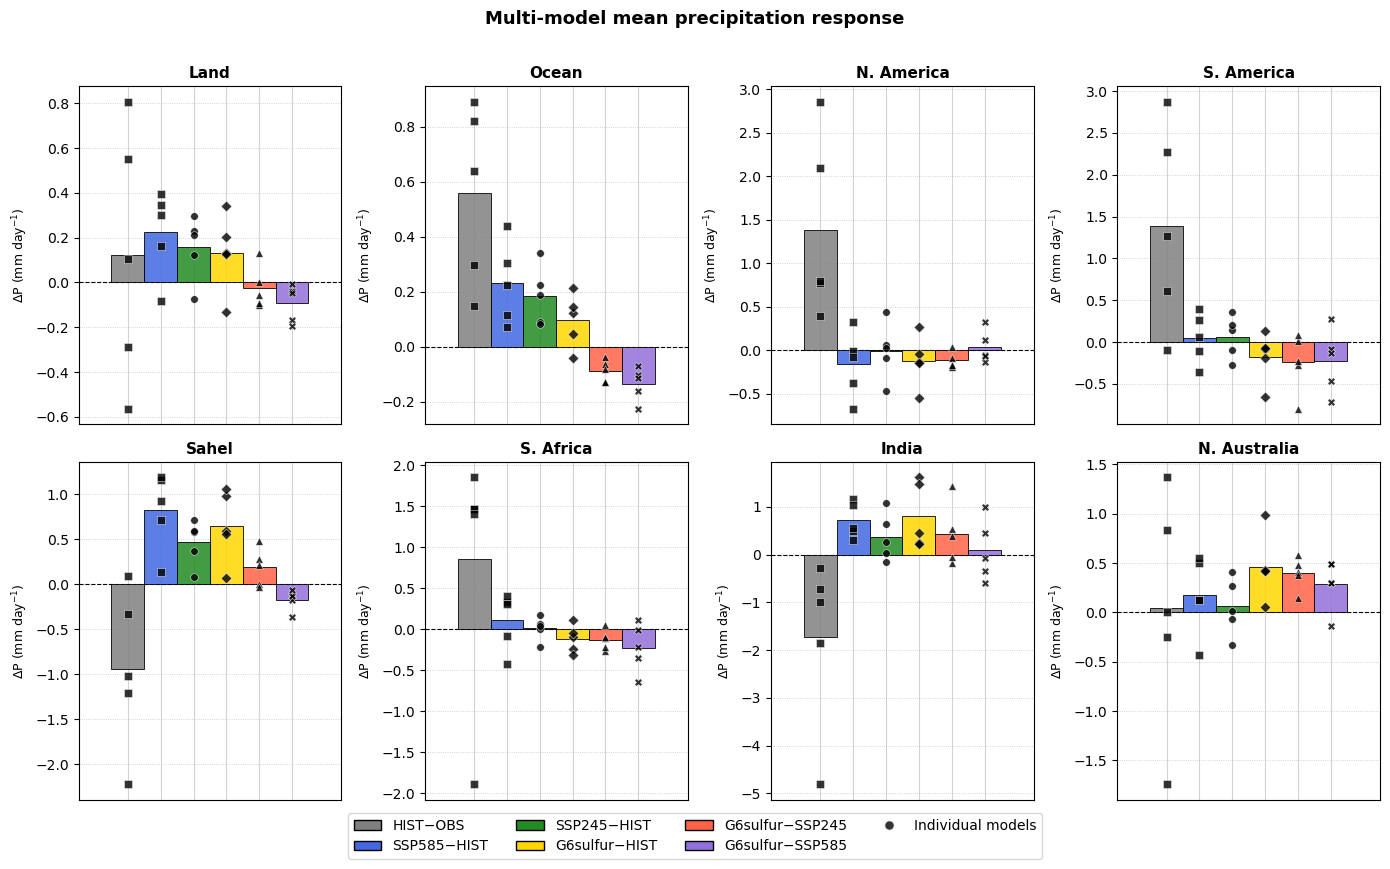

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# # ── pull named datasets from the single store dict ──────────────────────────
# bar_HIST_TRMM       = all_bar_data['bar_data_HIST19852014_minus_TRMM']
# bar_SSP585_HIST     = all_bar_data['bar_data_SSP58520212100_minus_HIST19212000']
# bar_SSP245_HIST     = all_bar_data['bar_data_SSP24520212100_minus_HIST19212000']
# bar_G6s_HIST        = all_bar_data['bar_data_G6sulfur20212100_minus_HIST19212000']
# bar_G6s_SSP245      = all_bar_data['bar_data_G6sulfur20212100_minus_SSP24520212100']
# bar_G6s_SSP585      = all_bar_data['bar_data_G6sulfur20212100_minus_SSP58520212100']

fig, axes = plt.subplots(2, 4, figsize=(14, 8))

width   = 0.15
offsets = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * width

bar_color = ['gray', 'royalblue', 'forestgreen', 'gold', 'tomato', 'mediumpurple']

# datasets = [
#     (bar_HIST_TRMM,   offsets[0], 's', bar_color[0], 'HIST−OBS'),
#     (bar_SSP585_HIST, offsets[1], 's', bar_color[1], 'SSP585−HIST'),   # fixed label
#     (bar_SSP245_HIST, offsets[2], 'o', bar_color[2], 'SSP245−HIST'),   # fixed label
#     (bar_G6s_HIST,    offsets[3], 'D', bar_color[3], 'G6sulfur−HIST'),
#     (bar_G6s_SSP245,  offsets[4], '^', bar_color[4], 'G6sulfur−SSP245'),
#     (bar_G6s_SSP585,  offsets[5], 'X', bar_color[5], 'G6sulfur−SSP585'),
# ]

datasets = [
    (bar_data_HIST_TRMM19852014_minus_TRMM,          offsets[0], 's', bar_color[0],   'HIST-OBS'),
    
    (bar_data_SSP58520212100_minus_HIST19212000,     offsets[1], 's', bar_color[1],   'SSP245−HIST'),
    (bar_data_SSP24520212100_minus_HIST19212000,     offsets[2], 'o', bar_color[2],   'SSP585−HIST'),
    (bar_data_G6sulfur20212100_minus_HIST19212000,   offsets[3], 'D', bar_color[3],   'G6sulfur−HIST'),
    (bar_data_G6sulfur20212100_minus_SSP24520212100, offsets[4], '^', bar_color[4],   'G6sulfur−SSP245'),
    (bar_data_G6sulfur20212100_minus_SSP58520212100, offsets[5], 'X', bar_color[5],   'G6sulfur−SSP585'),
]

panel_layout = [
    (0, 0, 'Land'),
    (0, 1, 'Ocean'),
    (0, 2, 'N. America'),
    (0, 3, 'S. America'),
    (1, 0, 'Sahel'),
    (1, 1, 'S. Africa'),
    (1, 2, 'India'),
    (1, 3, 'N. Australia'),
]

# Use any dataset to get label order — they're all the same
all_labels = bar_data_HIST_TRMM19852014_minus_TRMM['labels']
print("Available labels:", all_labels)

rng = np.random.default_rng(42)
x   = np.array([0])

for row, col, panel_label in panel_layout:
    ax = axes[row, col]

    try:
        i_label = list(all_labels).index(panel_label)
    except ValueError:
        ax.set_visible(False)
        print(f"Label '{panel_label}' not found, skipping")
        continue

    # Gray vertical guide lines at each bar center
    for offset in offsets:
        ax.axvline(x + offset, color='lightgray', linewidth=0.8,
                   linestyle='-', zorder=1)

    for data, offset, marker, color, leg_label in datasets:
        val = data['means'][i_label]
        ax.bar(x + offset, val, width=width,
               color=color, edgecolor='k', linewidth=0.7,
               alpha=0.85, zorder=3)

        pm = data['per_model_all'][i_label]
        ax.scatter(np.full(len(pm), float(x + offset)), pm,
                   marker=marker, color='k', s=30, zorder=5,
                   alpha=0.8, edgecolors='white', linewidths=0.4)

    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', zorder=2)
    ax.set_xticks([])
    ax.set_xlim(-0.6, 0.6)
    ax.set_title(panel_label, fontsize=11, fontweight='bold')
    ax.set_ylabel('$\\Delta$P (mm day$^{-1}$)', fontsize=9)
    ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7, zorder=2)

# Shared legend
legend_patches = [
    mpatches.Patch(facecolor=bar_color[0], edgecolor='k', label='HIST−OBS'),
    mpatches.Patch(facecolor=bar_color[1], edgecolor='k', label='SSP585−HIST'),
    mpatches.Patch(facecolor=bar_color[2], edgecolor='k', label='SSP245−HIST'),
    mpatches.Patch(facecolor=bar_color[3], edgecolor='k', label='G6sulfur−HIST'),
    mpatches.Patch(facecolor=bar_color[4], edgecolor='k', label='G6sulfur−SSP245'),
    mpatches.Patch(facecolor=bar_color[5], edgecolor='k', label='G6sulfur−SSP585'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
               markersize=7, alpha=0.8, label='Individual models'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=10, bbox_to_anchor=(0.5, -0.06))

plt.suptitle('Multi-model mean precipitation response',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("Rainfall_change_panels.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches

# fig, axes = plt.subplots(2, 4, figsize=(8, 10))

# width   = 0.15
# offsets = np.array([-2, -1, 0, 1, 2]) * width
# bar_color = ['black', 'blue', 'green', 'yellow', 'red', 'purple']

# datasets = [
#     (bar_data_HIST_TRMM19852014_minus_TRMM,          offsets[0], 's', bar_color[0],   'HIST-OBS'),
    
#     (bar_data_SSP58520212100_minus_HIST19212000,     offsets[1], 's', bar_color[1],   'SSP245−HIST'),
#     (bar_data_SSP24520212100_minus_HIST19212000,     offsets[2], 'o', bar_color[2],   'SSP585−HIST'),
#     (bar_data_G6sulfur20212100_minus_HIST19212000,   offsets[3], 'D', bar_color[3],   'G6sulfur−HIST'),
#     (bar_data_G6sulfur20212100_minus_SSP24520212100, offsets[4], '^', bar_color[4],   'G6sulfur−SSP245'),
#     (bar_data_G6sulfur20212100_minus_SSP58520212100, offsets[5], 'X', bar_color[5],   'G6sulfur−SSP585'),
# ]

# # Panel layout: (row, col) → list of label indices to show
# # Assumes bar labels order: Land, Ocean, N.America, S.America, Sahel, S.Africa, India, N.Australia
# panel_layout = [
#     (0, 0, 'Land'),
#     (0, 1, 'Ocean'),
#     (0, 2, 'N. America'),
#     (0, 3, 'S. America'),
#     (1, 0, 'Sahel'),
#     (1, 1, 'S. Africa'),
#     (1, 2, 'India'),
#     (1, 3, 'N. Australia'),
# ]

# # Get all labels from one dataset
# all_labels = bar_data_G6sulfur_SSP245['labels']
# print("Available labels:", all_labels)  # check order

# rng = np.random.default_rng(42)

# for row, col, panel_label in panel_layout:
#     ax = axes[row, col]

#     # Find index of this label
#     try:
#         i_label = list(all_labels).index(panel_label)
#     except ValueError:
#         ax.set_visible(False)
#         print(f"Label '{panel_label}' not found, skipping")
#         continue

#     x = np.array([0])  # single bar group per panel

#     for data, offset, marker, color, leg_label in datasets:
#         val = data['means'][i_label]
#         ax.bar(x + offset, val, width=width,
#                color=color, edgecolor='k', linewidth=0.7,
#                alpha=0.85, zorder=3)

#         pm     = data['per_model_all'][i_label]
#         # jitter = rng.uniform(-0.03, 0.03, size=len(pm))
#         # ax.scatter(x + offset + jitter, pm,
#         #            marker=marker, color='k', s=30, zorder=5,
#         #            alpha=0.8, edgecolors='white', linewidths=0.4)
#         ax.scatter(np.full(len(pm), float(x + offset)), pm,
#            marker=marker, color='k', s=30, zorder=5,
#            alpha=0.8, edgecolors='white', linewidths=0.4)

#     ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
#     ax.set_xticks([])
#     ax.set_title(panel_label, fontsize=11, fontweight='bold')
#     ax.set_ylabel('$\\Delta$P (mm day$^{-1}$)', fontsize=9)
#     ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7, zorder=1)

# # Shared legend at bottom
# legend_patches = [
#     mpatches.Patch(facecolor=bar_color[0], edgecolor='k', label='HIST-OBS'),
#     mpatches.Patch(facecolor=bar_color[1], edgecolor='k', label='SSP245−HIST'),
#     mpatches.Patch(facecolor=bar_color[2], edgecolor='k', label='SSP585−HIST'),
#     mpatches.Patch(facecolor=bar_color[3], edgecolor='k', label='G6sulfur−HIST'),
#     mpatches.Patch(facecolor=bar_color[4], edgecolor='k', label='G6sulfur−SSP245'),
#     mpatches.Patch(facecolor=bar_color[5], edgecolor='k', label='G6sulfur−SSP585'),
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
#                markersize=7, alpha=0.8, label='Individual models'),
# ]
# fig.legend(handles=legend_patches, loc='lower center', ncol=3,
#            fontsize=10, bbox_to_anchor=(0.5, -0.02))

# plt.suptitle('Multi-model mean precipitation response', fontsize=13,
#              fontweight='bold', y=1.01)
# plt.tight_layout()
# # plt.savefig("Rainfall_change_panels.png", dpi=150, bbox_inches="tight")
# plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches

# %store -r bar_data_G6sulfur_SSP245
# %store -r bar_data_G6sulfur_SSP585

# fig, ax = plt.subplots(figsize=(10, 8))

# n     = len(bar_data_G6sulfur_SSP245['labels'])
# x     = np.arange(n)
# width = 0.35

# datasets = [
#     (bar_data_G6sulfur_SSP245, -width/2, '',    'o', 'SSP2-4.5'),
#     (bar_data_G6sulfur_SSP585, +width/2, '///', 'X', 'SSP5-8.5'),
# ]

# rng = np.random.default_rng(42)

# for data, offset, hatch, marker, leg_label in datasets:
#     ax.bar(x + offset, data['means'], width=width,
#            color=data['colors'], edgecolor='k', linewidth=0.7,
#            alpha=0.85, hatch=hatch, zorder=3)

#     for i_bar, pm in enumerate(data['per_model_all']):
#         jitter = rng.uniform(-0.08, 0.08, size=len(pm))
#         ax.scatter(x[i_bar] + offset + jitter, pm,
#                    marker=marker, color='k', s=22, zorder=5,
#                    alpha=0.65, edgecolors='white', linewidths=0.4)

# ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
# ax.set_xticks(x)
# ax.set_xticklabels(bar_data_G6sulfur_SSP245['labels'], fontsize=10)
# ax.set_ylabel('$\\Delta$RESPONSE$_{G6sulfur}$ (mm day$^{-1}$)', fontsize=10)
# ax.set_title(
#     'G6sulfur multi-model mean precipitation response — SSP2-4.5 vs SSP5-8.5',
#     fontsize=11
# )
# ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7, zorder=1)

# legend_patches = [
#     mpatches.Patch(facecolor='grey', edgecolor='k',            label='SSP2-4.5'),
#     mpatches.Patch(facecolor='grey', edgecolor='k', hatch='///', label='SSP5-8.5'),
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
#                markersize=7, alpha=0.7, label='Models — SSP2-4.5'),
#     plt.Line2D([0], [0], marker='X', color='w', markerfacecolor='k',
#                markersize=7, alpha=0.7, label='Models — SSP5-8.5'),
# ]
# ax.legend(handles=legend_patches, fontsize=9, loc='upper right')

# plt.tight_layout()
# plt.show()
# fig.savefig("Rainfall_change_G6sulfur_SSP245_SSP585_2.png", dpi=150, bbox_inches="tight")

In [ ]:
# %store -r bar_data_SSP585_minus_HIST

In [ ]:
# bar_data_SSP585_minus_HIST

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches

# %store -r bar_data_SSP585_minus_HIST
# %store -r bar_data_SSP245_minus_HIST
# %store -r bar_data_G6sulfur_SSP245
# %store -r bar_data_G6sulfur_SSP585
# %store -r bar_data_G6sulfur_minus_HIST

# fig, ax = plt.subplots(figsize=(10, 8))

# n     = len(bar_data_G6sulfur_SSP245['labels'])
# x     = np.arange(n)
# width = 0.1  # narrower to fit 4 bars per group

# datasets = [
#     (bar_data_SSP245_minus_HIST, -3*width/2, '',    'o', 'SSP245−HIST'),
#     (bar_data_SSP585_minus_HIST, -1*width/2, '///', 'X', 'SSP585−HIST'),
#     (bar_data_G6sulfur_SSP245,   +1*width/2, '',    'o', 'G6sulfur−SSP245'),
#     (bar_data_G6sulfur_SSP585,   +3*width/2, '///', 'X', 'G6sulfur−SSP585'),
#     (bar_data_G6sulfur_minus_HIST,   +4*width/2, '///', 'X', 'G6sulfur−HIST'),
# ]

# rng = np.random.default_rng(42)

# for data, offset, hatch, marker, leg_label in datasets:
#     ax.bar(x + offset, data['means'], width=width,
#            color=data['colors'], edgecolor='k', linewidth=0.7,
#            alpha=0.85, hatch=hatch, zorder=3)

#     for i_bar, pm in enumerate(data['per_model_all']):
#         jitter = rng.uniform(-0.08, 0.08, size=len(pm))
#         ax.scatter(x[i_bar] + offset + jitter, pm,
#                    marker=marker, color='k', s=22, zorder=5,
#                    alpha=0.65, edgecolors='white', linewidths=0.4)

# ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
# ax.set_xticks(x)
# ax.set_xticklabels(bar_data_G6sulfur_SSP245['labels'], fontsize=10)
# ax.set_ylabel('$\\Delta$RESPONSE$_{G6sulfur}$ (mm day$^{-1}$)', fontsize=10)
# ax.set_title(
#     'G6sulfur multi-model mean precipitation response — SSP2-4.5 vs SSP5-8.5',
#     fontsize=11
# )
# ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7, zorder=1)

# legend_patches = [
#     mpatches.Patch(facecolor='grey', edgecolor='k',             label='SSP245−HIST'),
#     mpatches.Patch(facecolor='grey', edgecolor='k', hatch='///', label='SSP585−HIST'),
#     mpatches.Patch(facecolor='blue', edgecolor='k',             label='G6sulfur−SSP245'),
#     mpatches.Patch(facecolor='blue', edgecolor='k', hatch='///', label='G6sulfur−SSP585'),
#     mpatches.Patch(facecolor='blue', edgecolor='k', hatch='///', label='G6sulfur−HIST'),
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
#                markersize=7, alpha=0.7, label='Individual models'),
# ]
# ax.legend(handles=legend_patches, fontsize=9, loc='upper right')

# plt.tight_layout()
# plt.show()
# # fig.savefig("Rainfall_change_G6sulfur_SSP245_SSP585_2.png", dpi=150, bbox_inches="tight")

In [ ]:
# fig, ax = plt.subplots(figsize=(12, 6))
# n     = len(bar_data_G6sulfur_SSP245['labels'])
# x     = np.arange(n)
# width = 0.15  # each bar width

# # 5 bars: offsets centered around 0
# offsets = np.array([-2, -1, 0, 1, 2]) * width

# datasets = [
#     (bar_data_SSP245_minus_HIST,  offsets[0], '',     's', 'steelblue',  'SSP245−HIST'),
#     (bar_data_SSP585_minus_HIST,  offsets[1], '////', 'o', 'tomato',     'SSP585−HIST'),
#     (bar_data_G6sulfur_minus_HIST,offsets[2], 'xxx',  'D', 'purple',     'G6sulfur−HIST'),
#     (bar_data_G6sulfur_SSP245,    offsets[3], '...',  '^', 'goldenrod',  'G6sulfur−SSP245'),
#     (bar_data_G6sulfur_SSP585,    offsets[4], '\\\\', 'X', 'seagreen',   'G6sulfur−SSP585'),
# ]

# rng = np.random.default_rng(42)

# for data, offset, hatch, marker, color, leg_label in datasets:
#     ax.bar(x + offset, data['means'], width=width,
#            color=color, edgecolor='k', linewidth=0.7,
#            alpha=0.75, hatch=hatch, zorder=3)
#     for i_bar, pm in enumerate(data['per_model_all']):
#         jitter = rng.uniform(-0.03, 0.03, size=len(pm))  # tight jitter
#         ax.scatter(x[i_bar] + offset + jitter, pm,
#                    marker=marker, color='k', s=25, zorder=5,
#                    alpha=0.8, edgecolors='white', linewidths=0.4)

# ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
# ax.set_xticks(x)
# ax.set_xticklabels(bar_data_G6sulfur_SSP245['labels'], fontsize=10)
# ax.set_ylabel('$\\Delta$P (mm day$^{-1}$)', fontsize=10)
# ax.set_title('Multi-model mean precipitation response', fontsize=11)
# ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7, zorder=1)

# legend_patches = [
#     mpatches.Patch(facecolor='steelblue', edgecolor='k',              label='SSP245−HIST'),
#     mpatches.Patch(facecolor='tomato',    edgecolor='k', hatch='////', label='SSP585−HIST'),
#     mpatches.Patch(facecolor='purple',    edgecolor='k', hatch='xxx',  label='G6sulfur−HIST'),
#     mpatches.Patch(facecolor='goldenrod', edgecolor='k', hatch='...',  label='G6sulfur−SSP245'),
#     mpatches.Patch(facecolor='seagreen',  edgecolor='k', hatch='\\\\', label='G6sulfur−SSP585'),
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
#                markersize=7, alpha=0.8, label='Individual models'),
# ]
# ax.legend(handles=legend_patches, fontsize=9, loc='upper right')

# plt.tight_layout()
# # plt.savefig("Rainfall_change_G6sulfur_SSP245_SSP585_2.png", dpi=150, bbox_inches="tight")
# plt.show()

In [ ]:
# fig, axes = plt.subplots(2, 4, figsize=(8, 10))

# width   = 0.15
# offsets = np.array([-2, -1, 0, 1, 2]) * width
# bar_color = ['blue', 'green', 'yellow', 'red', 'purple']

# datasets = [
#     (bar_data_SSP245_minus_HIST,   offsets[0], 's', bar_color[0],   'SSP245−HIST'),
#     (bar_data_SSP585_minus_HIST,   offsets[1], 'o', bar_color[1],   'SSP585−HIST'),
#     (bar_data_G6sulfur_minus_HIST, offsets[2], 'D', bar_color[2],  'G6sulfur−HIST'),
#     (bar_data_G6sulfur_SSP245,     offsets[3], '^', bar_color[3],  'G6sulfur−SSP245'),
#     (bar_data_G6sulfur_SSP585,     offsets[4], 'X', bar_color[4],    'G6sulfur−SSP585'),
# ]

# # Panel layout: (row, col) → list of label indices to show
# # Assumes bar labels order: Land, Ocean, N.America, S.America, Sahel, S.Africa, India, N.Australia
# panel_layout = [
#     (0, 0, 'Land'),
#     (0, 1, 'Ocean'),
#     (0, 2, 'N. America'),
#     (0, 3, 'S. America'),
#     (1, 0, 'Sahel'),
#     (1, 1, 'S. Africa'),
#     (1, 2, 'India'),
#     (1, 3, 'N. Australia'),
# ]

# # Get all labels from one dataset
# all_labels = bar_data_G6sulfur_SSP245['labels']
# print("Available labels:", all_labels)  # check order

# rng = np.random.default_rng(42)

# for row, col, panel_label in panel_layout:
#     ax = axes[row, col]

#     # Find index of this label
#     try:
#         i_label = list(all_labels).index(panel_label)
#     except ValueError:
#         ax.set_visible(False)
#         print(f"Label '{panel_label}' not found, skipping")
#         continue

#     x = np.array([0])  # single bar group per panel

#     for data, offset, marker, color, leg_label in datasets:
#         val = data['means'][i_label]
#         ax.bar(x + offset, val, width=width,
#                color=color, edgecolor='k', linewidth=0.7,
#                alpha=0.85, zorder=3)

#         pm     = data['per_model_all'][i_label]
#         # jitter = rng.uniform(-0.03, 0.03, size=len(pm))
#         # ax.scatter(x + offset + jitter, pm,
#         #            marker=marker, color='k', s=30, zorder=5,
#         #            alpha=0.8, edgecolors='white', linewidths=0.4)
#         ax.scatter(np.full(len(pm), float(x + offset)), pm,
#            marker=marker, color='k', s=30, zorder=5,
#            alpha=0.8, edgecolors='white', linewidths=0.4)

#     ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
#     ax.set_xticks([])
#     ax.set_title(panel_label, fontsize=11, fontweight='bold')
#     ax.set_ylabel('$\\Delta$P (mm day$^{-1}$)', fontsize=9)
#     ax.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.7, zorder=1)

# # Shared legend at bottom
# legend_patches = [
#     mpatches.Patch(facecolor=bar_color[0],  edgecolor='k', label='SSP245−HIST'),
#     mpatches.Patch(facecolor=bar_color[1],  edgecolor='k', label='SSP585−HIST'),
#     mpatches.Patch(facecolor=bar_color[2], edgecolor='k', label='G6sulfur−HIST'),
#     mpatches.Patch(facecolor=bar_color[3], edgecolor='k', label='G6sulfur−SSP245'),
#     mpatches.Patch(facecolor=bar_color[4],   edgecolor='k', label='G6sulfur−SSP585'),
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
#                markersize=7, alpha=0.8, label='Individual models'),
# ]
# fig.legend(handles=legend_patches, loc='lower center', ncol=3,
#            fontsize=10, bbox_to_anchor=(0.5, -0.02))

# plt.suptitle('Multi-model mean precipitation response', fontsize=13,
#              fontweight='bold', y=1.01)
# plt.tight_layout()
# # plt.savefig("Rainfall_change_panels.png", dpi=150, bbox_inches="tight")
# plt.show()

In [ ]:
color[1]